In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy import signal

In [3]:
proc = np.load('20251219104504 Cam 1 20251219 104528_proc.npy', allow_pickle=True).item()
print(proc.keys())

dict_keys(['filenames', 'save_path', 'Ly', 'Lx', 'sbin', 'fullSVD', 'save_mat', 'Lybin', 'Lxbin', 'sybin', 'sxbin', 'LYbin', 'LXbin', 'avgframe', 'avgmotion', 'avgframe_reshape', 'avgmotion_reshape', 'motion', 'motSv', 'movSv', 'motMask', 'movMask', 'motMask_reshape', 'movMask_reshape', 'motSVD', 'movSVD', 'pupil', 'running', 'blink', 'rois', 'sy', 'sx'])


In [4]:
pupil = proc['pupil']
pupil

[{'area': array([553.06578043,  49.28664904,  50.10902594, ..., 475.69169604,
         483.04060576, 548.17167842], shape=(125992,)),
  'com': array([[18.60404438, 25.15259635],
         [18.69726606, 30.42469933],
         [18.70460485, 30.4087348 ],
         ...,
         [17.90449963, 24.08341963],
         [18.00469602, 23.72256641],
         [18.24429308, 24.86835034]], shape=(125992, 2)),
  'axdir': array([[[-0.16636762, -0.9860638 ],
          [-0.9860638 ,  0.16636762]],
  
         [[-0.38701443, -0.92207366],
          [-0.92207366,  0.38701443]],
  
         [[-0.38841332, -0.92148527],
          [-0.92148527,  0.38841332]],
  
         ...,
  
         [[ 0.1451914 , -0.98940359],
          [-0.98940359, -0.1451914 ]],
  
         [[ 0.11654211, -0.99318575],
          [-0.99318575, -0.11654211]],
  
         [[ 0.00643328, -0.99997931],
          [-0.99997931, -0.00643328]]], shape=(125992, 2, 2)),
  'axlen': array([[283.92845569, 109.155321  ],
         [ 17.17326486,  14

In [5]:
pupil_area = pupil[0]['area'] # 瞳孔面积
pupil_center = pupil[0]['com'] # 瞳孔中心坐标
pupil_orientation = pupil[0]['axdir'] # 方向向量
pupil_axes = pupil[0]['axlen'] # 椭圆轴长

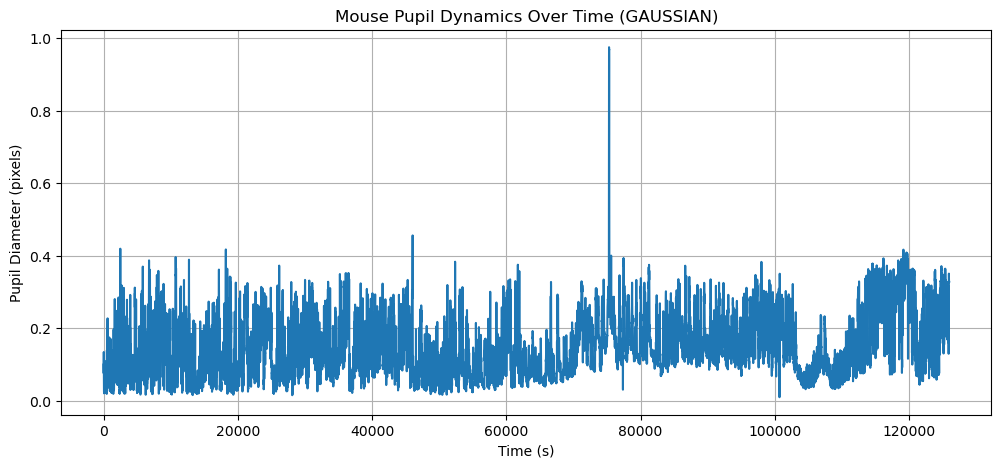

In [24]:
# 创建时间轴（假设视频帧率为30fps）
frame_rate = 50 # 请根据你的实际视频帧率修改
pupil_diameter = pupil_axes[:, 0] # 提取所有帧的长轴数据

time_axis = np.arange(len(pupil_diameter))  # 将帧数转换为秒

# 1. Min-max 标准化
data_min = np.min(pupil_diameter)
data_max = np.max(pupil_diameter)
normalized_data = (pupil_diameter - data_min) / (data_max - data_min)

filtered_diameter = gaussian_filter1d(normalized_data, sigma=4)

# 绘制瞳孔直径变化曲线
plt.figure(figsize=(12, 5))
plt.plot(time_axis, filtered_diameter)
plt.xlabel('Time (s)')
plt.ylabel('Pupil Diameter (pixels)')
plt.title('Mouse Pupil Dynamics Over Time (GAUSSIAN)')
plt.grid(True)
plt.show()

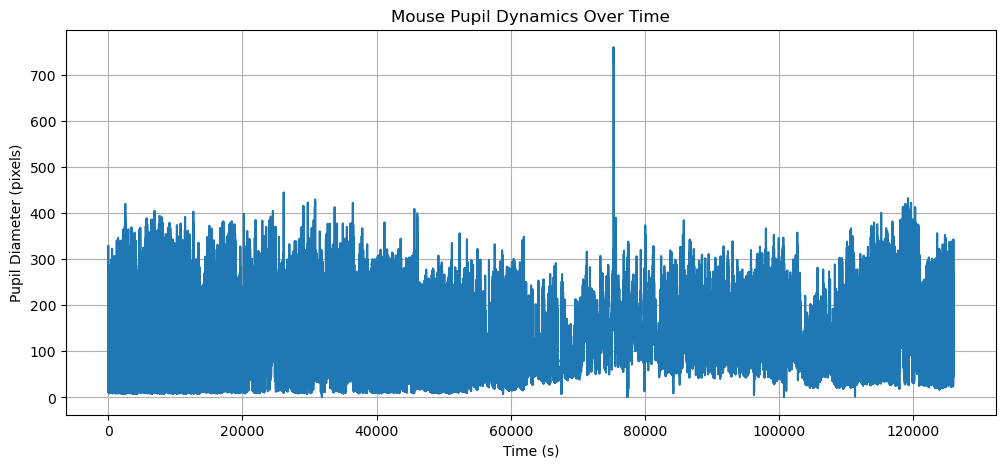

In [6]:
# 创建时间轴（假设视频帧率为30fps）
frame_rate = 50 # 请根据你的实际视频帧率修改
pupil_diameter = pupil_axes[:, 0] # 提取所有帧的长轴数据
time_axis = np.arange(len(pupil_diameter))  # 将帧数转换为秒

# 绘制瞳孔直径变化曲线
plt.figure(figsize=(12, 5))
plt.plot(time_axis, pupil_diameter)
plt.xlabel('Time (s)')
plt.ylabel('Pupil Diameter (pixels)')
plt.title('Mouse Pupil Dynamics Over Time')
plt.grid(True)
plt.show()

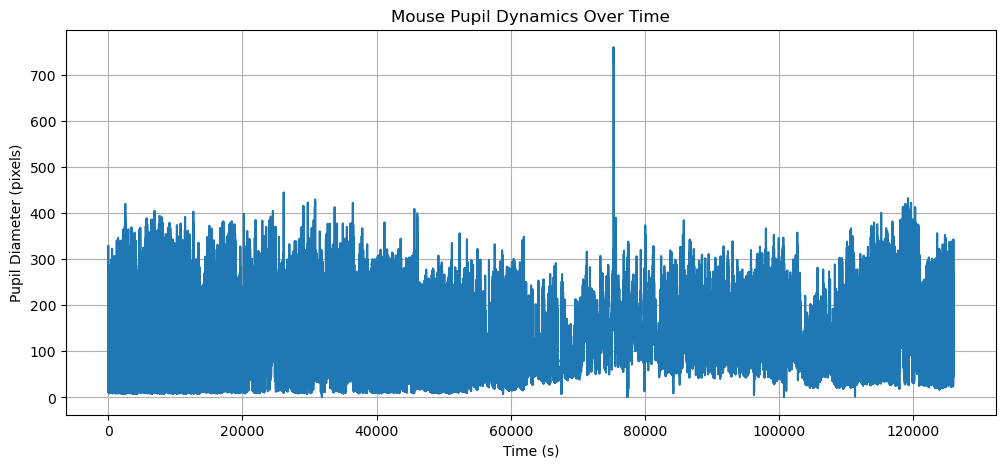

In [ ]:
# 创建时间轴（假设视频帧率为30fps）
frame_rate = 50 # 请根据你的实际视频帧率修改
pupil_diameter = pupil_axes[:, 0] # 提取所有帧的长轴数据
time_axis = np.arange(len(pupil_diameter))  # 将帧数转换为秒

# 绘制瞳孔直径变化曲线
plt.figure(figsize=(12, 5))
plt.plot(time_axis, pupil_diameter)
plt.xlabel('Time (s)')
plt.ylabel('Pupil Diameter (pixels)')
plt.title('Mouse Pupil Dynamics Over Time')
plt.grid(True)
plt.show()

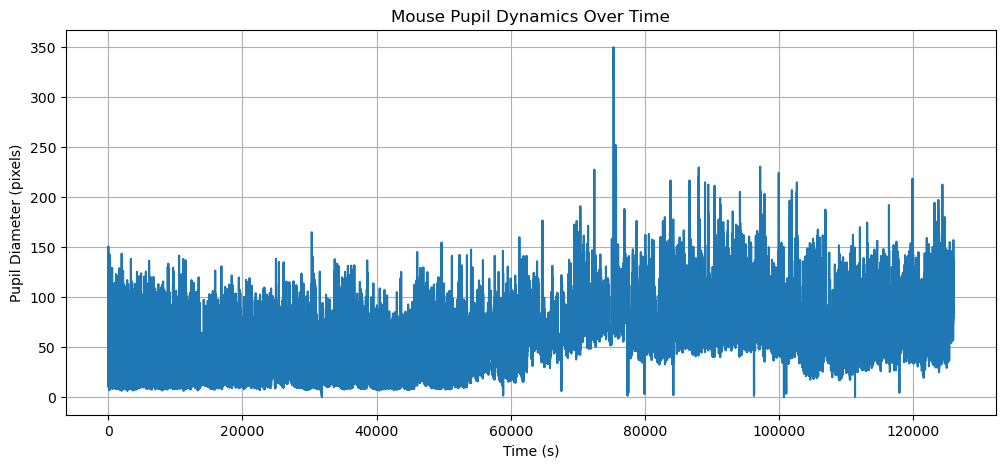

In [7]:
# 创建时间轴（假设视频帧率为30fps）
frame_rate = 50 # 请根据你的实际视频帧率修改
pupil_diameter = pupil_axes[:, 1] # 提取所有帧的长轴数据
time_axis = np.arange(len(pupil_diameter)) # 将帧数转换为秒

# 绘制瞳孔直径变化曲线
plt.figure(figsize=(12, 5))
plt.plot(time_axis, pupil_axes[:, 1])
plt.xlabel('Time (s)')
plt.ylabel('Pupil Diameter (pixels)')
plt.title('Mouse Pupil Dynamics Over Time')
plt.grid(True)
plt.show()

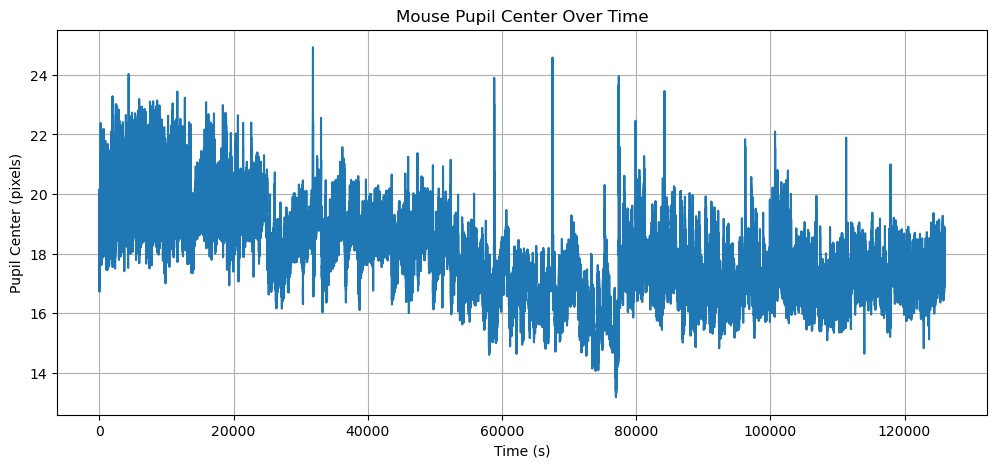

In [10]:
# 创建时间轴（假设视频帧率为30fps）

pupil_center = pupil_center[:, 0] # 提取所有帧的长轴数据
time_frame = np.arange(len(pupil_center))  # 将帧数转换为秒

# 绘制瞳孔中心变化曲线
plt.figure(figsize=(12, 5))
plt.plot(time_frame, pupil_center)
plt.xlabel('Time (s)')
plt.ylabel('Pupil Center (pixels)')
plt.title('Mouse Pupil Center Over Time')
plt.grid(True)
plt.show()

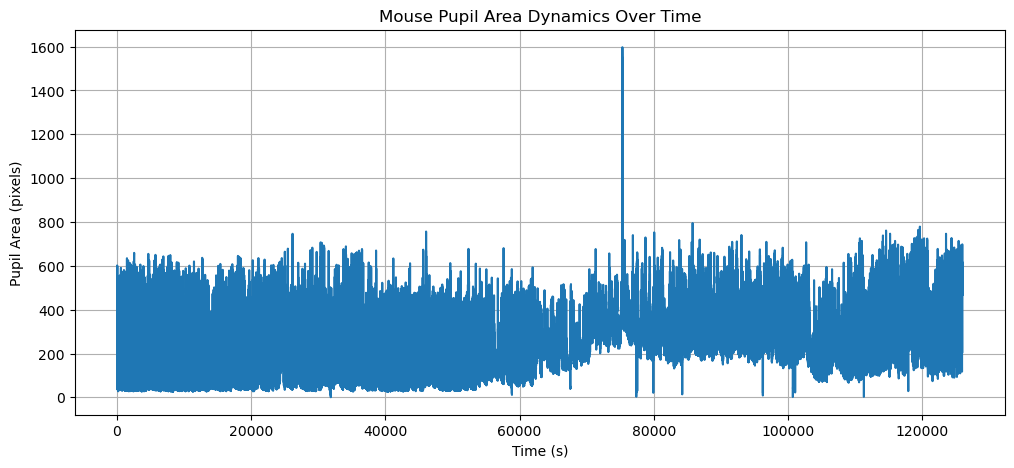

In [12]:
# 创建时间轴（假设视频帧率为30fps）


time_frame = np.arange(len(pupil_diameter))  # 将帧数转换为秒

# 绘制瞳孔直径变化曲线
plt.figure(figsize=(12, 5))
plt.plot(time_frame, pupil_area)
plt.xlabel('Time (s)')
plt.ylabel('Pupil Area (pixels)')
plt.title('Mouse Pupil Area Dynamics Over Time')
plt.grid(True)
plt.show()